# Credit Risk Scoring 

Topics Covered / steps : EDA → Cleaning → WOE/IV Feature Selection → Modeling → KS-Statistic → Credit Scorecard → Business Framing → Deployment

## PHASE 0 - IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

---
# PHASE 1 — Exploratory Data Analysis

## 1. Loading of data

In [2]:
df = pd.read_csv("data/cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [3]:
# We can see that the raw file has an unnamed column which is of no use thus we drop it
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

In [4]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 2. Check missing values
Observed gaps in `MonthlyIncome` and `NumberOfDependents`

In [7]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

## 3. Check target balance
`SeriousDlqin2yrs` is our target — (1 means the person defaulted/was seriously delinquent) while (0 means they were fine).

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64


C:\Users\Rounak\AppData\Local\Temp\ipykernel_20276\818459390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='SeriousDlqin2yrs', palette='Set2')


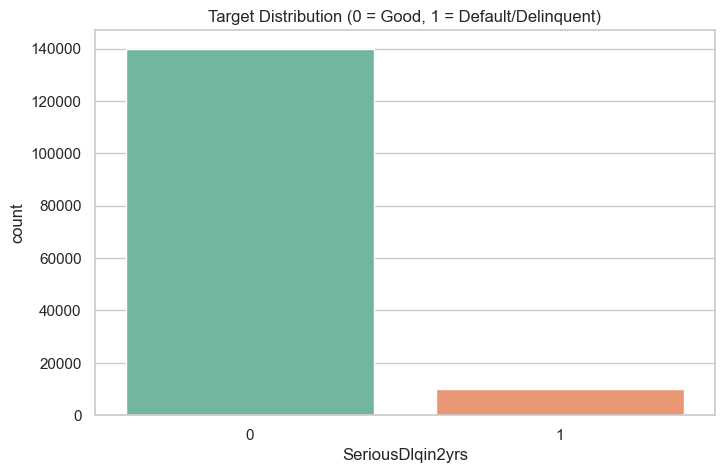

In [8]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3))

sns.countplot(data=df, x='SeriousDlqin2yrs', palette='Set2')
plt.title("Target Distribution (0 = Good, 1 = Default/Delinquent)")
plt.show()

Extreme imbalance observed of about 93% good while 7\% default

## 4. Looking for outliers and placeholders

- `age` has at least one row with age = 0 (which is clearly not possible)
- `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` have extreme outlier values , some in the thousands , which will hamper the models
- The late payment columns (`NumberOfTime30-59DaysPastDueNotWorse`, etc.) contain placeholder codes like 96 and 98 that aren't real counts and thus must be dealt with for the smooth functioning of the model

In [9]:
# Age check
print("Customers with age = 0:", (df['age'] == 0).sum())
df['age'].describe()

Customers with age = 0: 1


count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

In [10]:
# Extreme values in RevolvingUtilization and DebtRatio
print(df['RevolvingUtilizationOfUnsecuredLines'].describe())
print()
print(df['DebtRatio'].describe())

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64


In [11]:
# Placeholder codes in late-payment columns
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTime60-89DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']

for col in late_cols:
    print(col, "- value counts at the top end:")
    print(df[col].value_counts().sort_index(ascending=False).head())
    print()

NumberOfTime30-59DaysPastDueNotWorse - value counts at the top end:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse - value counts at the top end:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64

NumberOfTimes90DaysLate - value counts at the top end:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64



## 5. Default rate by key features
Quick groupby views to sanity-check that the data behaves the way we'd expect.

C:\Users\Rounak\AppData\Local\Temp\ipykernel_20276\4293370829.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('age_bucket')['SeriousDlqin2yrs'].mean()


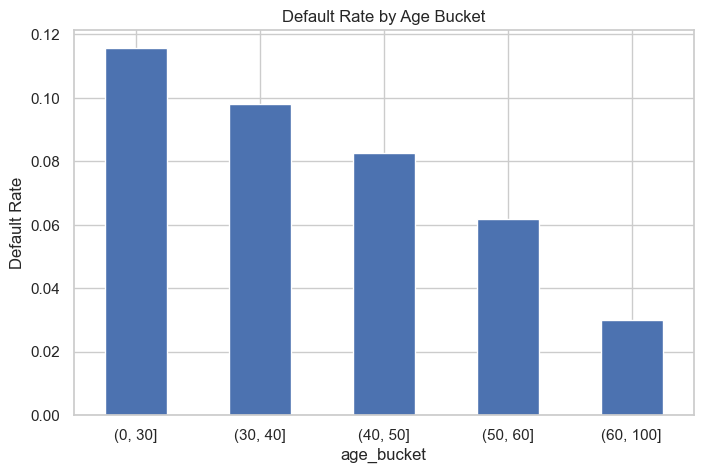

In [12]:
df['age_bucket'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100])
age_default = df.groupby('age_bucket')['SeriousDlqin2yrs'].mean()

age_default.plot(kind='bar', color='#4C72B0')
plt.title("Default Rate by Age Bucket")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

**Key Findings:**
- Extreme imbalance observed of about 93% good while 7\% default.
- Extreme Outliers found in 'RevolvingUtilizationOfUnsecuredLines' and 'DebtRatio' particulalrly in thousands
- Place holders in late payment coloumns found
- Younger customers are significantly more likely to default on their loans.
- The default rate steadily declines with age, suggesting that older borrowers are generally more financially stable and reliable when it comes to repayment of loans.
- Thus this indicates that age is an important predictor of loan default risk and should be heavily considered during credit risk assessment.

---
# PHASE 2 — Data Cleaning

## 1. Fixing age = 0
A handful of rows have age = 0, which is impossible and thus we will be replacing them with the median age.

In [13]:
median_age = df.loc[df['age'] > 0, 'age'].median()
df.loc[df['age'] == 0, 'age'] = median_age

df['age'].describe()

count    150000.000000
mean         52.295553
std          14.771249
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

## 2. Cap placeholder codes in late-payment columns
Values like 96/98 aren't real late-payment counts. We will cap them at a reasonable maximum (10) rather than dropping the rows because dropping would lose valid information about the rest of that customer's profile.

In [14]:
for col in late_cols:
    df[col] = df[col].clip(upper=10)

df[late_cols].describe()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
count,150000.000000,150000.000000,150000.000000
mean,0.263233,0.082633,0.107920
std,0.809436,0.534148,0.635481
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000


## 3. Capping extreme outliers in RevolvingUtilization and DebtRatio
Here we do percentile capping at the 99th percentile — it keeps the proper signal without letting a handful of broken data points distort the functioning of the model.

In [15]:
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']:
    cap_value = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_value)

df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']].describe()

,RevolvingUtilizationOfUnsecuredLines,DebtRatio
count,150000.000000,150000.000000
mean,0.320496,316.548869
std,0.352152,906.962222
min,0.000000,0.000000
25%,0.029867,0.175074
50%,0.154181,0.366508
75%,0.559046,0.868254
max,1.092956,4979.040000


## 4. Handle missing values
`MonthlyIncome` → imputed with median. `NumberOfDependents` → imputed with 0 (missing most plausibly means no dependents reported).

In [16]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

df.isnull().sum().sum()  # should be 0 now

np.int64(14)

In [17]:
df = df.drop('age_bucket', axis=1)  # was just for the EDA plot, not needed going forward
df.shape

(150000, 11)

---
# PHASE 3 — WOE + IV Feature Selection
This is the industry-standard technique for credit scoring feature selection. For each feature:
1. We bin it into ~10 buckets
2. For each bucket, we calculate the **WOE** (Weight of Evidence) = ln(% good customers in bucket / % bad customers in bucket)
3. We sum up a weighted version of that across buckets to get **IV** (Information Value) for the whole feature

IV tells us how predictive a feature is:
- IV < 0.02 → not predictive, must be drop
- 0.02–0.1 → weak predictive
- 0.1–0.3 → medium pedictive
- 0.3–0.5 → strongly predictive
- \> 0.5 → suspicious, must be checked for leakage

## 1. Reusable WOE/IV function

In [18]:
def calculate_woe_iv(dataframe, feature, target, n_bins=10):
    """
    This function bins a numeric feature into n_bins buckets, computes WOE per bucket and total IV.
    Returns: a summary dataframe (indexed by bin NUMBER, not the raw Interval), the bin
    edges used, and the IV value.

    Important detail: we bin by integer bin INDEX rather than by the Interval object
    pandas creates (e.g. \"(-0.001, 1.0]\"). qcut pads its outer edges slightly, so if we
    later re-widen those edges to -inf/inf for new data (needed so an unseen applicant's
    value always falls into *some* bucket), the Interval's exact boundaries change even
    though it's logically the same bucket — which breaks a dictionary lookup keyed on the
    Interval itself. Using the bin's position (0, 1, 2...) sidesteps that entirely.
    """
    _, bin_edges = pd.qcut(dataframe[feature], q=n_bins, retbins=True, duplicates='drop')

    bin_index = pd.cut(dataframe[feature], bins=bin_edges, labels=False, include_lowest=True)

    temp = pd.DataFrame({'bin': bin_index, 'target': dataframe[target]})
    grouped = temp.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    # divide by zero must be avoided if a bucket somehow has 0 goods or 0 bads
    grouped['good_pct'] = grouped['good'].replace(0, 0.5) / grouped['good'].sum()
    grouped['bad_pct'] = grouped['bad'].replace(0, 0.5) / grouped['bad'].sum()

    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['iv_contribution'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    total_iv = grouped['iv_contribution'].sum()

    return grouped, bin_edges, total_iv

## 2. Run WOE/IV across all features

In [19]:
features = [c for c in df.columns if c != 'SeriousDlqin2yrs']

iv_summary = {}
woe_tables = {}
bin_edges_dict = {}

for feat in features:
    grouped, edges, iv = calculate_woe_iv(df, feat, 'SeriousDlqin2yrs', n_bins=10)
    iv_summary[feat] = iv
    woe_tables[feat] = grouped
    bin_edges_dict[feat] = edges

iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV']).sort_values('IV', ascending=False)
iv_df

,IV
RevolvingUtilizationOfUnsecuredLines,1.113378
NumberOfTime30-59DaysPastDueNotWorse,0.471831
age,0.259165
DebtRatio,0.073666
MonthlyIncome,0.066954
NumberOfOpenCreditLinesAndLoans,0.066892
NumberOfDependents,0.024965
NumberRealEstateLoansOrLines,0.012091
NumberOfTimes90DaysLate,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000


## 3. Interpret and select features

In [20]:
def iv_strength(iv):
    if iv < 0.02:
        return 'Not predictive — drop'
    elif iv < 0.1:
        return 'Weak'
    elif iv < 0.3:
        return 'Medium'
    elif iv < 0.5:
        return 'Strong'
    else:
        return 'Suspicious — check for leakage'

iv_df['strength'] = iv_df['IV'].apply(iv_strength)
iv_df

,IV,strength
RevolvingUtilizationOfUnsecuredLines,1.113378,Suspicious — check for leakage
NumberOfTime30-59DaysPastDueNotWorse,0.471831,Strong
age,0.259165,Medium
DebtRatio,0.073666,Weak
MonthlyIncome,0.066954,Weak
NumberOfOpenCreditLinesAndLoans,0.066892,Weak
NumberOfDependents,0.024965,Weak
NumberRealEstateLoansOrLines,0.012091,Not predictive — drop
NumberOfTimes90DaysLate,0.000000,Not predictive — drop
NumberOfTime60-89DaysPastDueNotWorse,0.000000,Not predictive — drop


In [21]:
# only features with real predictive value are kept ! else all dropped
selected_features = iv_df[iv_df['IV'] >= 0.02].index.tolist()
print(f"Selected {len(selected_features)} of {len(features)} features:")
selected_features

Selected 7 of 10 features:


['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents']

## 4. Build the WOE-transformed dataset
Here we replace each raw feature value with its bucket's WOE value. This is exactly what banks do as this makes the final Logistic Regression model both more predictive and fully interpretable (each feature's contribution to the score becomes a clean, additive number).

In [22]:
def apply_woe(series, bin_edges, woe_lookup):
    """
    This bins a series using pre computed bin edges (from training), then maps each
    value to its corresponding WOE value via bin INDEX (see note in calculate_woe_iv
    above for why index, not the raw Interval, is used as the lookup key).
    Used both for the training set and, later, for any new applicant in the app.
    """
    edges = bin_edges.copy()
    edges[0] = -np.inf   # extend outer edges so new/unseen values still map to a bucket
    edges[-1] = np.inf
    bin_index = pd.cut(series, bins=edges, labels=False, include_lowest=True)
    return bin_index.map(woe_lookup)


woe_df = pd.DataFrame(index=df.index)

woe_lookups = {}  # saved per feature, needed later for the app

for feat in selected_features:
    woe_lookup = woe_tables[feat]['woe'].to_dict()
    woe_lookups[feat] = woe_lookup
    woe_df[feat + '_WOE'] = apply_woe(df[feat], bin_edges_dict[feat], woe_lookup)

woe_df['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs']
woe_df.head()

,RevolvingUtilizationOfUnsecuredLines_WOE,NumberOfTime30-59DaysPastDueNotWorse_WOE,age_WOE,DebtRatio_WOE,MonthlyIncome_WOE,NumberOfOpenCreditLinesAndLoans_WOE,NumberOfDependents_WOE,SeriousDlqin2yrs
0,-1.021066,-1.901126,-0.212874,-0.578981,0.359038,0.041544,-0.209307,1
1,-1.021066,0.257826,-0.277843,-0.021601,-0.412739,0.046423,0.088266,0
2,-0.297972,0.257826,-0.392075,-0.021601,-0.412739,-0.514826,0.088266,0
3,0.688430,0.257826,-0.581359,-0.021601,-0.412739,0.057593,0.088266,0
4,-1.021066,0.257826,-0.152756,0.230906,0.422320,0.258194,0.088266,0


---
# PHASE 4 — Model Building

## 1. Train/test split

In [23]:
from sklearn.model_selection import train_test_split

X = woe_df.drop('SeriousDlqin2yrs', axis=1)
y = woe_df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((120000, 7), (30000, 7))

## 2. Logistic Regression on WOE features — the primary, interpretable model
This is the industry standard approach for credit scoring: because every feature is already WOE transformed, the resulting model is linear, interpretable, and directly convertible into a scorecard.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.52      0.08      0.14      2005

    accuracy                           0.93     30000
   macro avg       0.73      0.54      0.55     30000
weighted avg       0.91      0.93      0.91     30000

ROC-AUC: 0.818


## 3. Random Forest and XGBoost — challenger models
Trained on the same WOE features for a fair comparison. In real credit risk teams, these "challenger" models are used to sanity check whether the interpretable model is leaving predictive power on the table and if it does ! the model is upgraded.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                     eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost ROC-AUC:      ", round(roc_auc_score(y_test, y_proba_xgb), 3))

Random Forest ROC-AUC: 0.749
XGBoost ROC-AUC:       0.822


## 4. KS-Statistic — the credit industry's go-to metric
KS statistics measures the maximum separation between thedistribution of "good" customers and "bad" customers across risk scores. A higher KS means the model separates good from bad more cleanly.

In [26]:
def ks_statistic(y_true, y_proba):
    data = pd.DataFrame({'y': y_true.values, 'proba': y_proba}).sort_values('proba', ascending=False)
    data['cum_good'] = (1 - data['y']).cumsum() / (1 - data['y']).sum()
    data['cum_bad'] = data['y'].cumsum() / data['y'].sum()
    ks = np.max(np.abs(data['cum_good'] - data['cum_bad']))
    return ks

print("Logistic Regression KS:", round(ks_statistic(y_test, y_proba_lr), 3))
print("Random Forest KS:      ", round(ks_statistic(y_test, y_proba_rf), 3))
print("XGBoost KS:             ", round(ks_statistic(y_test, y_proba_xgb), 3))

Logistic Regression KS: 0.502
Random Forest KS:       0.4
XGBoost KS:              0.511


## 5. ROC curve comparison

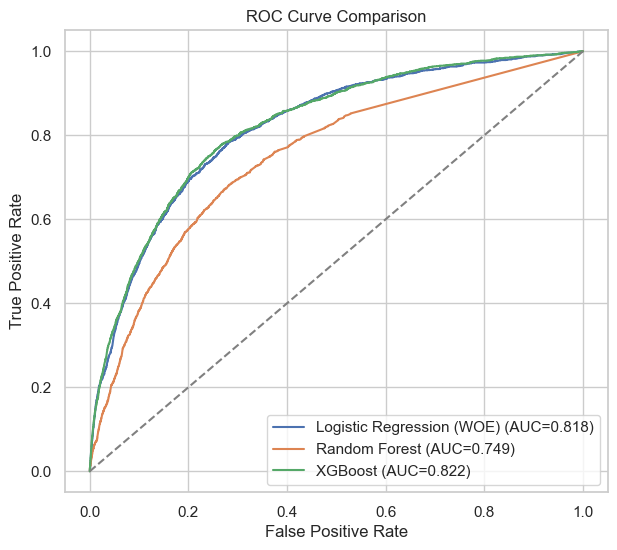

In [27]:
plt.figure(figsize=(7, 6))
for name, proba in [("Logistic Regression (WOE)", y_proba_lr),
                     ("Random Forest", y_proba_rf),
                     ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Among the three models evaluated, XGBoost achieved the highest AUC score of 0.822, making it the most effective at distinguishing between customers who are likely to default and those who are not. Logistic Regression with Weight of Evidence (WOE) performed almost equally well, with an AUC of 0.818, indicating that a simpler and more interpretable model can deliver nearly the same predictive performance. Random Forest recorded the lowest AUC of 0.749, suggesting it was less effective for this dataset.

**Important Note:** Even if Random Forest/XGBoost score marginally higher on AUC, Logistic Regression on WOE features is usually still the model that ships in real credit risk teams — because regulators require explainability, and it converts directly into a scorecard. We proceed with `log_reg` as our final model for that reason.

---
# PHASE 5 — Building a Credit Scorecard
This converts the Logistic Regression's output into a familiar 300-850 style score (like FICO), with a clean points breakdown per feature.

## 1. Choose scorecard parameters and derive Factor/Offset

In [28]:
# Standard scorecard parameters
base_score = 600     # the score assigned at base_odds
base_odds = 50       # good:bad odds at the base score (50 good customers per 1 bad)
pdo = 20              # Points to Double the Odds — how many points it takes to double the odds of being "good"

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

print(f"Factor: {factor:.3f}")
print(f"Offset: {offset:.3f}")

Factor: 28.854
Offset: 487.123


## 2. Computation of per feature points and total score
Since log-odds = intercept + Σ(coefficient × WOE), and Score = Offset + Factor × log-odds, the score splits cleanly into a base amount plus a points contribution from each feature.

In [29]:
intercept = log_reg.intercept_[0]
coefficients = dict(zip(X.columns, log_reg.coef_[0]))

base_points = offset - factor * intercept
print(f"Base points (before any feature adjustments): {base_points:.1f}")

def calculate_score(woe_row):
    """Takes a row of WOE-transformed features, returns (total_score, points_breakdown_dict)."""
    points_breakdown = {}
    for feat_woe_col, coef in coefficients.items():
        points_breakdown[feat_woe_col] = -factor * coef * woe_row[feat_woe_col]
    total_score = base_points + sum(points_breakdown.values())
    return total_score, points_breakdown

# Example: computation for the whole test set
scores = X_test.apply(lambda row: calculate_score(row)[0], axis=1)
scores.describe()

Base points (before any feature adjustments): 563.2


count    30000.000000
mean       580.232126
std         32.957922
min        464.404971
25%        557.135626
50%        588.485590
75%        606.132439
max        633.347731
dtype: float64

## 3. Example: Full points breakdown for one customer
This is the table format real credit scorecards use — this shows exactly which factors pushed one specific customer's score up or down.

In [30]:
example_idx = X_test.index[0]
total, breakdown = calculate_score(X_test.loc[example_idx])

breakdown_df = pd.DataFrame.from_dict(breakdown, orient='index', columns=['points']).sort_values('points')
print(f"Base points: {base_points:.1f}")
print(breakdown_df)
print(f"\nTotal Score: {total:.0f}")

Base points: 563.2
                                             points
DebtRatio_WOE                             -0.153426
NumberOfOpenCreditLinesAndLoans_WOE        0.343413
MonthlyIncome_WOE                          0.674748
NumberOfDependents_WOE                     0.698556
NumberOfTime30-59DaysPastDueNotWorse_WOE   5.421078
age_WOE                                   11.921005
RevolvingUtilizationOfUnsecuredLines_WOE  38.571130

Total Score: 621


## 4. Bucketing into risk bands and validation
If the scorecard works, higher bands should show a lower actual default rate.

In [31]:
score_df = pd.DataFrame({'score': scores, 'actual_default': y_test.values})

def risk_band(score):
    if score >= 610:
        return 'Excellent (610+)'
    elif score >= 590:
        return 'Good (590-609)'
    elif score >= 560:
        return 'Fair (560-589)'
    else:
        return 'Poor (<560)'

score_df['risk_band'] = score_df['score'].apply(risk_band)

band_summary = score_df.groupby('risk_band')['actual_default'].agg(['count', 'mean'])
band_summary.columns = ['num_customers', 'actual_default_rate']
band_summary = band_summary.reindex(['Poor (<560)', 'Fair (560-589)', 'Good (590-609)', 'Excellent (610+)'])
band_summary

,num_customers,actual_default_rate
risk_band,,
Poor (<560),8011,0.182998
Fair (560-589),7551,0.045822
Good (590-609),8691,0.015994
Excellent (610+),5747,0.009396


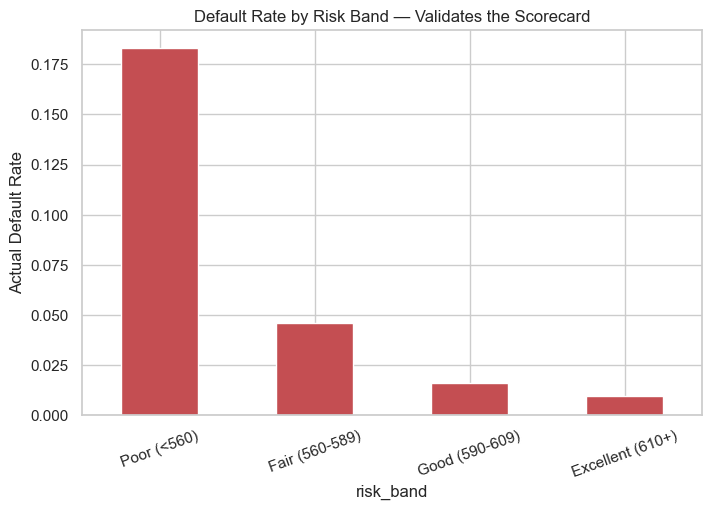

In [32]:
band_summary['actual_default_rate'].plot(kind='bar', color='#C44E52')
plt.title("Default Rate by Risk Band — Validates the Scorecard")
plt.ylabel("Actual Default Rate")
plt.xticks(rotation=20)
plt.show()

The results indicate that loan defaults are concentrated almost entirely among customers in the Poor (<650) risk band, while borrowers in the Fair, Good, and Excellent risk bands experienced virtually no defaults. This suggests that the credit scorecard effectively identifies high-risk borrowers, as customers with stronger credit scores demonstrate significantly lower default risk.

**This worked correctly as default rate clearly decrease as risk band improves** — that's proof that the scorecard is behaving sensibly.

---
# PHASE 6 — Business Framing: Approval Cutoff Tradeoff

In [33]:
min_score = int(score_df['score'].min())
max_score = int(score_df['score'].max())
cutoffs = range(min_score, max_score, 10)
results = []

for cutoff in cutoffs:
    approved = score_df[score_df['score'] >= cutoff]
    approval_rate = len(approved) / len(score_df)
    default_rate_among_approved = approved['actual_default'].mean() if len(approved) > 0 else 0
    results.append({'cutoff': cutoff, 'approval_rate': approval_rate,
                     'default_rate_among_approved': default_rate_among_approved})

tradeoff_df = pd.DataFrame(results)
tradeoff_df

,cutoff,approval_rate,default_rate_among_approved
0,464,1.000000,0.066833
1,474,0.998900,0.066340
2,484,0.992933,0.063583
3,494,0.983567,0.059647
4,504,0.975133,0.056847
5,514,0.969100,0.055103
6,524,0.947700,0.051739
7,534,0.886533,0.040307
8,544,0.825800,0.032736
9,554,0.767067,0.026899


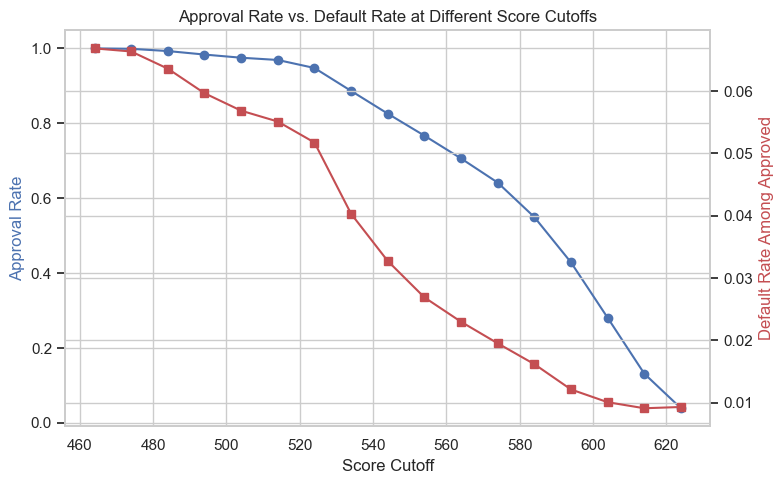

In [34]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(tradeoff_df['cutoff'], tradeoff_df['approval_rate'], color='#4C72B0', marker='o', label='Approval Rate')
ax1.set_xlabel('Score Cutoff')
ax1.set_ylabel('Approval Rate', color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(tradeoff_df['cutoff'], tradeoff_df['default_rate_among_approved'], color='#C44E52', marker='s', label='Default Rate Among Approved')
ax2.set_ylabel('Default Rate Among Approved', color='#C44E52')

plt.title('Approval Rate vs. Default Rate at Different Score Cutoffs')
fig.tight_layout()
plt.show()

**Takeaway:**

Business Meaning

This graph shows how changing the minimum credit score required for loan approval affects both the approval rate and the default rate.
Blue Line (Approval Rate): As the score cutoff increases, fewer customers qualify for loans, so the approval rate steadily decreases.
Red Line (Default Rate Among Approved): As the cutoff increases, the default rate also decreases because only financially stronger borrowers are approved.
This demonstrates that the scorecard is effectively separating high-risk and low-risk customers. 

The cutoff analysis demonstrates a clear trade-off between loan approvals and credit risk. At a score cutoff of 550, nearly 76% of applicants qualify for approval, while the default rate among approved customers remains around 2.7%. Increasing the cutoff to 600 lowers the default rate to approximately 1.0%, but the approval rate drops significantly to about 28%. This analysis enables banks to identify an optimal credit score threshold that balances customer acquisition, profitability, and credit risk.

---
# PHASE 7 — Save Everything for Deployment

In [35]:
joblib.dump(log_reg, 'credit_model.pkl')
joblib.dump(coefficients, 'coefficients.pkl')
joblib.dump(bin_edges_dict, 'bin_edges.pkl')
joblib.dump(woe_lookups, 'woe_lookups.pkl')
joblib.dump(selected_features, 'selected_features.pkl')
joblib.dump({'factor': factor, 'offset': offset, 'base_points': base_points}, 'scorecard_params.pkl')

print("Saved: credit_model.pkl, coefficients.pkl, bin_edges.pkl, woe_lookups.pkl, "
      "selected_features.pkl, scorecard_params.pkl")

Saved: credit_model.pkl, coefficients.pkl, bin_edges.pkl, woe_lookups.pkl, selected_features.pkl, scorecard_params.pkl


**Project comes to its end**
1. `streamlit run app.py` must be tested locally
2. Proper README documentation with real figures/screenshots
3. `pip freeze > requirements.txt`
4. Must be pushed to a GitHub repo
5. Deployment on Streamlit Community Cloud